In [ ]:
# NOTHING OS — Notebook Styling
from IPython.display import HTML, display

display(HTML('''
<style>
  @import url('https://fonts.googleapis.com/css2?family=Share+Tech+Mono&family=Space+Mono&display=swap');

  :root {
    --nothing-black:   #0A0A0A;
    --nothing-surface: #111111;
    --nothing-border:  #2A2A2A;
    --nothing-white:   #F5F5F5;
    --nothing-gray-1:  #CCCCCC;
    --nothing-gray-2:  #888888;
    --nothing-gray-3:  #555555;
    --nothing-red:     #FF1C1C;
    --font-ndot:       'Share Tech Mono', monospace;
    --font-body:       'Space Mono', monospace;
  }

  body, .jp-Notebook {
    background: var(--nothing-black) !important;
    font-family: var(--font-body) !important;
  }

  .jp-Cell { border-radius: 0 !important; }

  .jp-InputArea-editor, .jp-CodeCell .jp-Editor {
    background: var(--nothing-surface) !important;
    border: 1px solid var(--nothing-border) !important;
    border-radius: 0 !important;
    font-family: var(--font-body) !important;
    font-size: 12px !important;
  }

  .jp-OutputArea-output {
    background: #0D0D0D !important;
    border-left: 2px solid var(--nothing-border) !important;
    font-family: var(--font-body) !important;
    color: var(--nothing-gray-1) !important;
    font-size: 12px !important;
  }

  .jp-MarkdownOutput h1, .jp-MarkdownOutput h2, .jp-MarkdownOutput h3 {
    font-family: var(--font-ndot) !important;
    color: var(--nothing-white) !important;
    letter-spacing: 0.1em;
    text-transform: uppercase;
    border-bottom: 1px solid var(--nothing-border) !important;
    padding-bottom: 8px;
  }

  .jp-MarkdownOutput h1 { font-size: 22px !important; }
  .jp-MarkdownOutput h2 { font-size: 16px !important; }
  .jp-MarkdownOutput h3 { font-size: 13px !important; color: var(--nothing-gray-2) !important; }

  .jp-MarkdownOutput p, .jp-MarkdownOutput li {
    color: var(--nothing-gray-2) !important;
    font-family: var(--font-body) !important;
    font-size: 12px !important;
  }

  .jp-MarkdownOutput code {
    background: var(--nothing-surface) !important;
    color: var(--nothing-red) !important;
    border: 1px solid var(--nothing-border) !important;
    border-radius: 0 !important;
    padding: 1px 5px;
    font-size: 11px !important;
  }

  .jp-Toolbar {
    background: #070707 !important;
    border-bottom: 1px solid var(--nothing-border) !important;
  }
</style>
'''))

# And configure matplotlib globally:
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor': '#0A0A0A', 'axes.facecolor': '#111111',
    'axes.edgecolor': '#2A2A2A', 'axes.labelcolor': '#888888',
    'text.color': '#888888', 'xtick.color': '#555555', 'ytick.color': '#555555',
    'grid.color': '#2A2A2A', 'grid.linewidth': 0.5, 'grid.linestyle': ':',
    'axes.grid': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'monospace', 'figure.titlesize': 11,
    'legend.facecolor': '#111111', 'legend.edgecolor': '#2A2A2A',
    'lines.linewidth': 1.5, 'axes.titlesize': 10, 'axes.labelsize': 9,
    'axes.titlecolor': '#F5F5F5',
})

NOTHING_RED    = '#FF1C1C'
NOTHING_WHITE  = '#F5F5F5'
NOTHING_GRAY   = '#888888'
NOTHING_DIM    = '#555555'
NOTHING_MUTED  = '#3A3A3A'


# M5 Forecasting - XGBoost & LSTM

This notebook trains and evaluates two machine learning approaches for demand forecasting:
1. **XGBoost**: Trained independently for different horizons using Optuna for hyperparameter search.
2. **LSTM**: Trained with a sliding window approach using PyTorch Lightning.

Finally, we compare their performance against the ARIMA baseline.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import optuna
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl

sys.path.append(os.path.abspath('../'))
from src.data.loader import M5Loader
from src.data.feature_engineering import create_base_features
from src.models.baseline import calculate_metrics

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Data Preparation

In [2]:
print("Loading Data...")
loader = M5Loader(data_dir='../data')
calendar, sales, prices = loader.load_all()


d_cols = [c for c in sales.columns if c.startswith('d_')]
sales['total_sales'] = sales[d_cols].sum(axis=1)
top_200 = sales.sort_values('total_sales', ascending=False).head(200)
top_200 = top_200.drop(columns=['total_sales'])

id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_long = top_200.melt(id_vars=id_cols, var_name='d', value_name='sales')
d_to_date = dict(zip(calendar['d'], pd.to_datetime(calendar['date'])))
df_long['date'] = df_long['d'].map(d_to_date)
df_long = df_long.sort_values(['id', 'date']).reset_index(drop=True)

print("Engineering Features...")
df_feat = create_base_features(df_long)

dates = np.sort(df_feat['date'].unique())
split_idx = int(len(dates) * 0.9)
train_date_end = dates[split_idx]

print(f"Train end date: {train_date_end}")

INFO:src.data.loader:Loading all M5 datasets...
INFO:src.data.loader:Loading calendar data...
INFO:src.data.loader:Loading sales data...


Loading Data...


INFO:src.data.loader:Loading prices data...


Engineering Features...
Train end date: 2015-11-10T00:00:00.000000


## 2. XGBoost (Multi-Horizon)

In [4]:
horizons = [1, 7, 14, 28]
df_xgb = df_feat.copy()

for h in horizons:
    df_xgb[f'y_{h}'] = df_xgb.groupby('id')['sales'].shift(-h)

df_xgb = df_xgb.dropna().reset_index(drop=True)

train_xgb = df_xgb[df_xgb['date'] <= train_date_end]
test_xgb = df_xgb[df_xgb['date'] > train_date_end]

features = ['day_of_week', 'day_of_month', 'month', 'year']

xgb_results = []
best_xgb_models = {}

for h in horizons:
    print(f"\n--- Optimizing XGBoost for Horizon: {h} ---")
    target = f'y_{h}'
    
    def optimize_xgb(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        }
        
        val_date = train_date_end - pd.Timedelta(days=28)
        X_t = train_xgb[train_xgb['date'] <= val_date][features]
        y_t = train_xgb[train_xgb['date'] <= val_date][target]
        X_v = train_xgb[train_xgb['date'] > val_date][features]
        y_v = train_xgb[train_xgb['date'] > val_date][target]
        
        model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1, tree_method='hist')
        model.fit(X_t, y_t)
        preds = model.predict(X_v)
        _, _, wmape = calculate_metrics(y_v.values, preds)
        return wmape

    study = optuna.create_study(direction='minimize')
    study.optimize(optimize_xgb, n_trials=50)
    
    print(f"Best WMAPE: {study.best_value:.4f} with params: {study.best_params}")
    
   
    model = xgb.XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, tree_method='hist')
    model.fit(train_xgb[features], train_xgb[target])
    best_xgb_models[h] = model
    
    
    preds = model.predict(test_xgb[features])
    mae, rmse, wmape = calculate_metrics(test_xgb[target].values, preds)
    xgb_results.append({'Horizon': h, 'Model': 'XGBoost', 'MAE': mae, 'RMSE': rmse, 'WMAPE': wmape})


--- Optimizing XGBoost for Horizon: 1 ---
Best WMAPE: 0.6894 with params: {'max_depth': 3, 'learning_rate': 0.08412040342404584, 'n_estimators': 150, 'subsample': 0.9091625388024797}

--- Optimizing XGBoost for Horizon: 7 ---
Best WMAPE: 0.6917 with params: {'max_depth': 4, 'learning_rate': 0.0905787819817221, 'n_estimators': 141, 'subsample': 0.827896776440833}

--- Optimizing XGBoost for Horizon: 14 ---
Best WMAPE: 0.6987 with params: {'max_depth': 3, 'learning_rate': 0.07490948900505538, 'n_estimators': 149, 'subsample': 0.8003095746179237}

--- Optimizing XGBoost for Horizon: 28 ---
Best WMAPE: 0.7245 with params: {'max_depth': 5, 'learning_rate': 0.07169687507011559, 'n_estimators': 134, 'subsample': 0.8861545399391367}


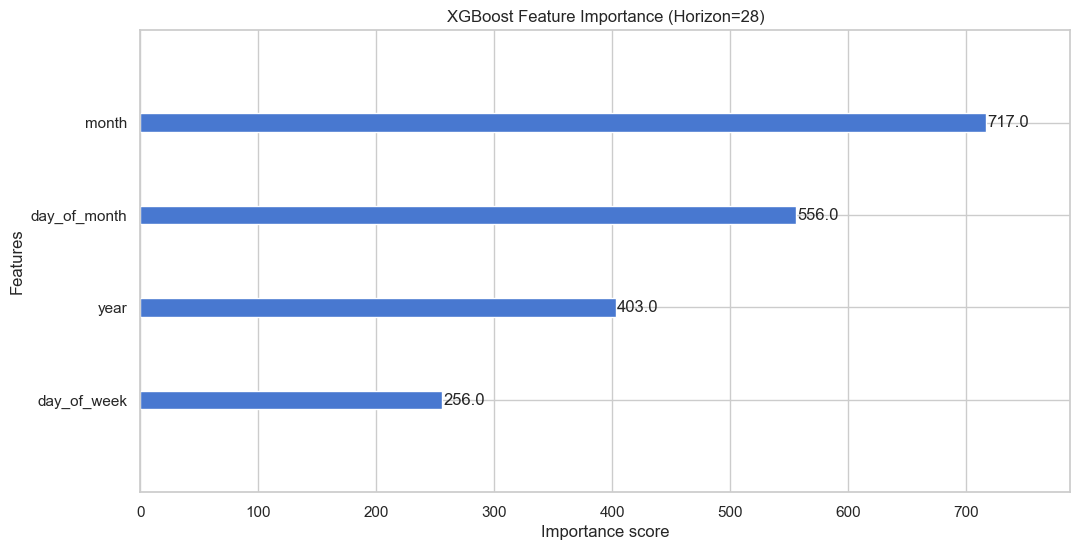

In [ ]:
# Plot Feature Importance for h=28
xgb.plot_importance(best_xgb_models[28], importance_type='weight', title="XGBoost Feature Importance (Horizon=28)")
plt.show()

## 3. LSTM (Sliding Window)

In [ ]:
df_lstm = df_feat.copy()


print("Scaling data per item...")
df_lstm['sales_mean'] = df_lstm.groupby('id')['sales'].transform('mean')
df_lstm['sales_std'] = df_lstm.groupby('id')['sales'].transform('std')

df_lstm['sales_std'] = df_lstm['sales_std'].replace(0, 1)
df_lstm['sales_scaled'] = (df_lstm['sales'] - df_lstm['sales_mean']) / df_lstm['sales_std']

train_lstm = df_lstm[df_lstm['date'] <= train_date_end]
test_lstm = df_lstm[df_lstm['date'] > train_date_end]

class SlidingWindowDataset(Dataset):
    def __init__(self, df, lookback=56, horizon=28):
        self.X, self.y, self.means, self.stds = [], [], [], []
        for item, group in df.groupby('id'):
            values = group['sales_scaled'].values
            mean = group['sales_mean'].iloc[0]
            std = group['sales_std'].iloc[0]
            if len(values) > lookback + horizon:
                for i in range(len(values) - lookback - horizon + 1):
                    self.X.append(values[i : i+lookback])
                    self.y.append(values[i+lookback : i+lookback+horizon])
                    self.means.append(mean)
                    self.stds.append(std)
                    
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)
        self.means = torch.tensor(np.array(self.means), dtype=torch.float32)
        self.stds = torch.tensor(np.array(self.stds), dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.means[idx], self.stds[idx]

print("Building Datasets (this might take a moment)...")
train_dataset = SlidingWindowDataset(train_lstm)
val_dataset = SlidingWindowDataset(test_lstm)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0)

Scaling data per item...
Building Datasets (this might take a moment)...


In [ ]:
class DemandLSTM(pl.LightningModule):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, output_size=28):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.criterion = nn.L1Loss()
        self.save_hyperparameters()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :]) 
        return out

    def training_step(self, batch, batch_idx):
        x, y, _, _ = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y, _, _ = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

print("Training LSTM...")
model = DemandLSTM()
trainer = pl.Trainer(max_epochs=3, accelerator='auto', enable_progress_bar=True)
trainer.fit(model, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Training LSTM...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm      │ LSTM   │  199 K │ train │     0 │
│ 1 │ fc        │ Linear │  3.6 K │ train │     0 │
│ 2 │ criterion │ L1Loss │      0 │ train │     0 │
└───┴───────────┴────────┴────────┴───────┴───────┘

Trainable params: 202 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 202 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=3` reached.


In [ ]:

model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for x, y, means, stds in val_loader:
        preds = model(x)
        
        preds = (preds * stds.unsqueeze(-1)) + means.unsqueeze(-1)
        y = (y * stds.unsqueeze(-1)) + means.unsqueeze(-1)
        
        all_preds.append(preds.numpy())
        all_trues.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_trues = np.concatenate(all_trues)


all_preds = np.maximum(all_preds, 0)

lstm_results = []
for h in horizons:
    y_true_h = all_trues[:, h-1]
    y_pred_h = all_preds[:, h-1]
    mae, rmse, wmape = calculate_metrics(y_true_h, y_pred_h)
    lstm_results.append({'Horizon': h, 'Model': 'LSTM', 'MAE': mae, 'RMSE': rmse, 'WMAPE': wmape})

## 4. Comparison vs ARIMA Baseline


--- Model WMAPE Comparison ---


,ARIMA Baseline,XGBoost,LSTM
Horizon,,,
1,0.634501,0.664802,0.311973
7,0.804116,0.661926,0.340879
14,0.561224,0.658444,0.363696
28,0.877655,0.642312,0.374571


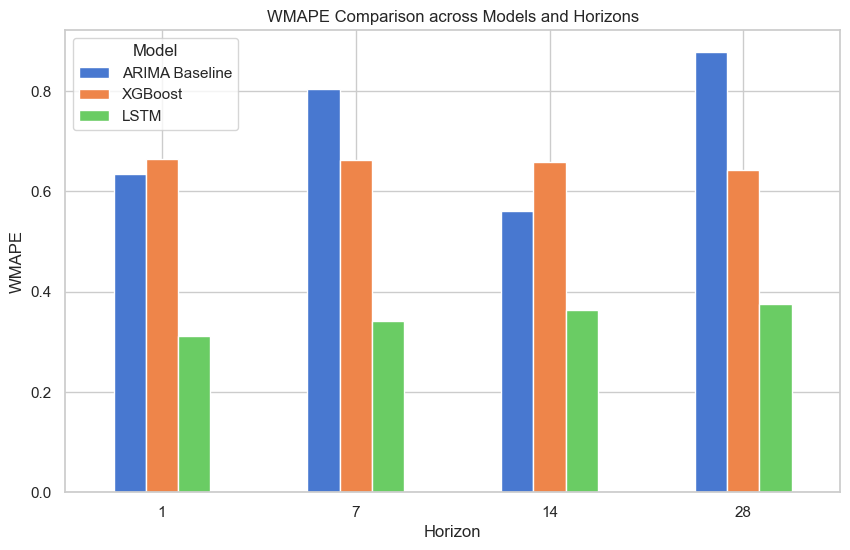

In [ ]:

try:
    baseline_df = pd.read_csv('../logs/eda/baseline_wmape_benchmark.csv', index_col='Horizon')
    arima_wmape = baseline_df['arima_forecast']
except FileNotFoundError:
    print("Baseline benchmark not found. Ensure 02_baseline_arima.ipynb is run first.")
    arima_wmape = pd.Series({1: np.nan, 7: np.nan, 14: np.nan, 28: np.nan})

#
xgb_df = pd.DataFrame(xgb_results).set_index('Horizon')['WMAPE'].rename('XGBoost')
lstm_df = pd.DataFrame(lstm_results).set_index('Horizon')['WMAPE'].rename('LSTM')

comparison = pd.DataFrame({
    'ARIMA Baseline': arima_wmape,
    'XGBoost': xgb_df,
    'LSTM': lstm_df
})

print("\n--- Model WMAPE Comparison ---")
display(comparison)

comparison.plot(kind='bar', figsize=(10, 6))
plt.title("WMAPE Comparison across Models and Horizons")
plt.ylabel("WMAPE")
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.show()